# FireFusion Data Engineering: SMAP Soil Moisture Data Exploration for Bushfire Prediction

## Overview
This notebook explores the **SMAP L4 Global 3-hourly 9 km EASE-Grid Surface and Root Zone Soil Moisture Geophysical Data** source and extracts Australia-specific soil moisture information from multiple downloaded `.h5` files.

The main goal is to:
- load and inspect the downloaded SMAP HDF5 files
- extract **surface soil moisture** and **root zone soil moisture**
- filter the data to **Australia only**
- visualize the results
- create a clean **CSV dataset**
- explain how this data can support **bushfire / forest fire prediction**

## Why this dataset matters
Soil moisture is one of the most important environmental indicators for bushfire prediction.

- **Surface soil moisture** helps indicate how dry the top layer of land is.
- **Root zone soil moisture** helps measure deeper moisture conditions in the soil.
- Lower soil moisture usually means **drier land and vegetation**, which can increase fire risk.
- When combined with other variables like temperature, wind speed, humidity, and fire occurrence data, soil moisture becomes a strong feature for a machine learning model.

## Files used
This notebook uses the following downloaded SMAP files:

1. `SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5`
2. `SMAP_L4_SM_gph_20240101T133000_Vv8010_001.h5`
3. `SMAP_L4_SM_gph_20240102T133000_Vv8010_001.h5`
4. `SMAP_L4_SM_gph_20240103T103000_Vv8010_001.h5`
5. `SMAP_L4_SM_gph_20240103T223000_Vv8010_001.h5`

## Final output
This notebook will generate:
- Australia-only surface soil moisture maps
- Australia-only root zone soil moisture maps
- a combined CSV file for downstream ML use

In [20]:
# Import required libraries

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Step 1: Define the downloaded SMAP files

The following cell defines the list of downloaded HDF5 files that will be processed.

In [21]:
# List of all downloaded SMAP files

file_list = [
    "SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5",
    "SMAP_L4_SM_gph_20240101T133000_Vv8010_001.h5",
    "SMAP_L4_SM_gph_20240102T133000_Vv8010_001.h5",
    "SMAP_L4_SM_gph_20240103T103000_Vv8010_001.h5",
    "SMAP_L4_SM_gph_20240103T223000_Vv8010_001.h5"
]

print("Total files:", len(file_list))
for f in file_list:
    print("-", f)

Total files: 5
- SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5
- SMAP_L4_SM_gph_20240101T133000_Vv8010_001.h5
- SMAP_L4_SM_gph_20240102T133000_Vv8010_001.h5
- SMAP_L4_SM_gph_20240103T103000_Vv8010_001.h5
- SMAP_L4_SM_gph_20240103T223000_Vv8010_001.h5


## Step 2: Verify that all files exist

This step ensures that the notebook can find all required files before processing begins.

In [22]:
# Check whether files exist in the current working directory

missing_files = []

for f in file_list:
    if not Path(f).exists():
        missing_files.append(f)

if missing_files:
    print("Missing files:")
    for f in missing_files:
        print("-", f)
else:
    print("All files found successfully.")

All files found successfully.


## Step 3: Open one sample file and inspect its structure

Before processing all files, it is useful to inspect one file and confirm the available keys and variables.

In [23]:
# Open one sample file and inspect the structure

sample_file = h5py.File(file_list[0], "r")

print("Top-level keys:")
print(list(sample_file.keys()))

print("\nKeys inside Geophysical_Data:")
print(list(sample_file["Geophysical_Data"].keys()))

Top-level keys:
['EASE2_global_projection', 'Geophysical_Data', 'Metadata', 'cell_column', 'cell_lat', 'cell_lon', 'cell_row', 'time', 'x', 'y']

Keys inside Geophysical_Data:
['baseflow_flux', 'depth_to_water_table_from_surface', 'free_surface_water_on_peat_flux', 'heat_flux_ground', 'heat_flux_latent', 'heat_flux_sensible', 'height_lowatmmodlay', 'land_evapotranspiration_flux', 'land_fraction_saturated', 'land_fraction_snow_covered', 'land_fraction_unsaturated', 'land_fraction_wilting', 'leaf_area_index', 'mwrtm_vegopacity', 'net_downward_longwave_flux', 'net_downward_shortwave_flux', 'overland_runoff_flux', 'precipitation_total_surface_flux', 'radiation_longwave_absorbed_flux', 'radiation_shortwave_downward_flux', 'sm_profile', 'sm_profile_pctl', 'sm_profile_wetness', 'sm_rootzone', 'sm_rootzone_pctl', 'sm_rootzone_wetness', 'sm_surface', 'sm_surface_wetness', 'snow_depth', 'snow_mass', 'snow_melt_flux', 'snowfall_surface_flux', 'soil_temp_layer1', 'soil_temp_layer2', 'soil_temp_lay

## Step 4: Define the Australia region

To focus on the project scope, this notebook filters the data to Australia only.

The approximate bounding box used is:
- Latitude: -44 to -10
- Longitude: 112 to 154

In [24]:
# Australia bounding box

AUS_LAT_MIN = -44
AUS_LAT_MAX = -10
AUS_LON_MIN = 112
AUS_LON_MAX = 154

## Step 5: Create a reusable function to process one SMAP file

This function:
- opens a file
- extracts latitude and longitude
- extracts surface and root zone soil moisture
- cleans invalid values
- filters to Australia
- adds the source file name and timestamp
- returns a clean DataFrame

In [25]:
def process_smap_file(file_name):
    """
    Process one SMAP HDF5 file and return an Australia-only DataFrame.
    """
    
    with h5py.File(file_name, "r") as f:
        # Extract core arrays
        lat = f["cell_lat"][:]
        lon = f["cell_lon"][:]
        surface = f["Geophysical_Data"]["sm_surface"][:]
        rootzone = f["Geophysical_Data"]["sm_rootzone"][:]
        time_data = f["time"][:]
        
        # Replace invalid values with NaN
        surface = np.where(surface < 0, np.nan, surface)
        rootzone = np.where(rootzone < 0, np.nan, rootzone)
        
        # Create Australia mask
        australia_mask = (
            (lat >= AUS_LAT_MIN) & (lat <= AUS_LAT_MAX) &
            (lon >= AUS_LON_MIN) & (lon <= AUS_LON_MAX)
        )
        
        # Flatten arrays into tabular form
        df = pd.DataFrame({
            "latitude": lat.flatten(),
            "longitude": lon.flatten(),
            "surface_soil_moisture": surface.flatten(),
            "rootzone_soil_moisture": rootzone.flatten()
        })
        
        # Keep only Australia rows
        df = df[
            (df["latitude"] >= AUS_LAT_MIN) & (df["latitude"] <= AUS_LAT_MAX) &
            (df["longitude"] >= AUS_LON_MIN) & (df["longitude"] <= AUS_LON_MAX)
        ]
        
        # Remove invalid rows
        df = df.dropna().copy()
        
        # Add source file information
        df["source_file"] = file_name
        
        # Try to add timestamp from filename
        # Example: SMAP_L4_SM_gph_20240101T133000_Vv8010_001.h5
        try:
            timestamp_str = file_name.split("_")[4]
            df["timestamp"] = pd.to_datetime(timestamp_str, format="%Y%m%dT%H%M%S")
        except Exception:
            df["timestamp"] = pd.NaT
        
        return df

## Step 6: Process all files and combine them into one dataset

This step runs the processing function on all files and merges the results into a single DataFrame.

In [26]:
# Process all files and combine results

all_dfs = []

for file_name in file_list:
    print("Processing:", file_name)
    df_temp = process_smap_file(file_name)
    print("Rows extracted:", len(df_temp))
    all_dfs.append(df_temp)

combined_df = pd.concat(all_dfs, ignore_index=True)

print("\nCombined dataset shape:", combined_df.shape)
combined_df.head()

Processing: SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5
Rows extracted: 97102
Processing: SMAP_L4_SM_gph_20240101T133000_Vv8010_001.h5
Rows extracted: 97102
Processing: SMAP_L4_SM_gph_20240102T133000_Vv8010_001.h5
Rows extracted: 97102
Processing: SMAP_L4_SM_gph_20240103T103000_Vv8010_001.h5
Rows extracted: 97102
Processing: SMAP_L4_SM_gph_20240103T223000_Vv8010_001.h5
Rows extracted: 97102

Combined dataset shape: (485510, 6)


,latitude,longitude,surface_soil_moisture,rootzone_soil_moisture,source_file,timestamp
0,-10.0414,119.922203,0.103387,0.183653,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00
1,-10.0414,120.015564,0.262688,0.328916,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00
2,-10.0414,120.108925,0.268914,0.324156,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00
3,-10.0414,120.202286,0.269646,0.335752,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00
4,-10.0414,120.295647,0.278558,0.342466,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00


## Step 7: Inspect the combined dataset

This step checks the structure, sample rows, and summary information of the final combined dataset.

In [27]:
# Display dataset information

print("Combined dataset columns:")
print(combined_df.columns.tolist())

print("\nFirst 5 rows:")
display(combined_df.head())

print("\nSummary statistics:")
display(combined_df.describe())

Combined dataset columns:
['latitude', 'longitude', 'surface_soil_moisture', 'rootzone_soil_moisture', 'source_file', 'timestamp']

First 5 rows:


,latitude,longitude,surface_soil_moisture,rootzone_soil_moisture,source_file,timestamp
0,-10.0414,119.922203,0.103387,0.183653,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00
1,-10.0414,120.015564,0.262688,0.328916,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00
2,-10.0414,120.108925,0.268914,0.324156,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00
3,-10.0414,120.202286,0.269646,0.335752,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00
4,-10.0414,120.295647,0.278558,0.342466,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00



Summary statistics:


,latitude,longitude,surface_soil_moisture,rootzone_soil_moisture,timestamp
count,485510.000000,485510.000000,485510.000000,485510.000000,485510
mean,-25.316721,134.430450,0.106073,0.125796,2024-01-02 11:42:00
min,-43.670822,112.920128,0.000106,0.015220,2023-12-31 22:30:00
25%,-30.026934,125.990669,0.044282,0.028266,2024-01-01 13:30:00
50%,-25.412697,134.953323,0.077332,0.109586,2024-01-02 13:30:00
75%,-20.739166,143.262451,0.151055,0.203365,2024-01-03 10:30:00
max,-10.041400,153.998962,0.731293,0.911922,2024-01-03 22:30:00
std,6.339168,10.337484,0.078553,0.095928,NaN


## Step 8: Verify the moisture value ranges

Soil moisture values should be realistic and usually lie between 0 and 1 in volumetric units.

In [28]:
# Check min and max values

surface_min = combined_df["surface_soil_moisture"].min()
surface_max = combined_df["surface_soil_moisture"].max()

root_min = combined_df["rootzone_soil_moisture"].min()
root_max = combined_df["rootzone_soil_moisture"].max()

print("Surface soil moisture range:", surface_min, "to", surface_max)
print("Root zone soil moisture range:", root_min, "to", root_max)

Surface soil moisture range: 0.00010618853 to 0.7312934
Root zone soil moisture range: 0.015220201 to 0.9119216


## Step 9: Create a function to plot Australia-only maps from one file

To improve readability, the map is cropped to Australia instead of showing the full world.

In [29]:
def plot_australia_maps(file_name):
    """
    Plot Australia-only surface and root zone soil moisture maps from one file.
    """
    
    with h5py.File(file_name, "r") as f:
        lat = f["cell_lat"][:]
        lon = f["cell_lon"][:]
        surface = f["Geophysical_Data"]["sm_surface"][:]
        rootzone = f["Geophysical_Data"]["sm_rootzone"][:]

        # Clean invalid values
        surface = np.where(surface < 0, np.nan, surface)
        rootzone = np.where(rootzone < 0, np.nan, rootzone)

        # Australia mask
        aus_mask = (
            (lat >= AUS_LAT_MIN) & (lat <= AUS_LAT_MAX) &
            (lon >= AUS_LON_MIN) & (lon <= AUS_LON_MAX)
        )

        # Find bounding box
        rows, cols = np.where(aus_mask)
        rmin, rmax = rows.min(), rows.max()
        cmin, cmax = cols.min(), cols.max()

        # Crop arrays
        lat_crop = lat[rmin:rmax+1, cmin:cmax+1]
        lon_crop = lon[rmin:rmax+1, cmin:cmax+1]
        surface_crop = surface[rmin:rmax+1, cmin:cmax+1]
        rootzone_crop = rootzone[rmin:rmax+1, cmin:cmax+1]

        # Mask only Australia region
        local_mask = (
            (lat_crop >= AUS_LAT_MIN) & (lat_crop <= AUS_LAT_MAX) &
            (lon_crop >= AUS_LON_MIN) & (lon_crop <= AUS_LON_MAX)
        )

        surface_crop = np.where(local_mask, surface_crop, np.nan)
        rootzone_crop = np.where(local_mask, rootzone_crop, np.nan)

        # Plot surface
        plt.figure(figsize=(8, 10))
        plt.pcolormesh(lon_crop, lat_crop, surface_crop, shading="auto", cmap="viridis")
        plt.colorbar(label="Surface Soil Moisture (m³/m³)")
        plt.title(f"Australia Surface Soil Moisture\n{file_name}")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.show()

        # Plot root zone
        plt.figure(figsize=(8, 10))
        plt.pcolormesh(lon_crop, lat_crop, rootzone_crop, shading="auto", cmap="viridis")
        plt.colorbar(label="Root Zone Soil Moisture (m³/m³)")
        plt.title(f"Australia Root Zone Soil Moisture\n{file_name}")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.show()

## Step 10: Visualize one sample file

The following cell visualizes Australia-specific surface and root zone soil moisture from one representative file.

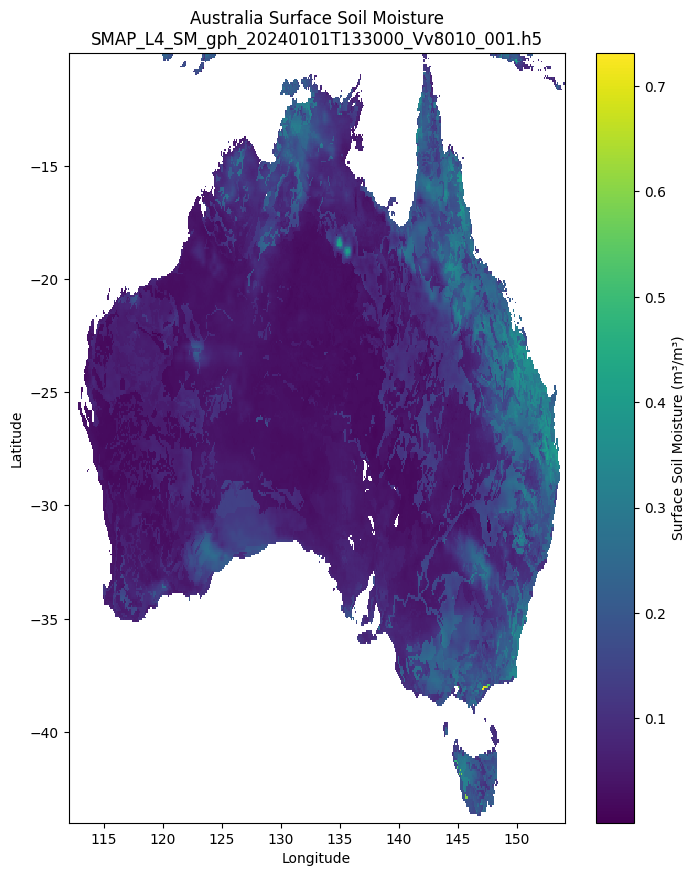

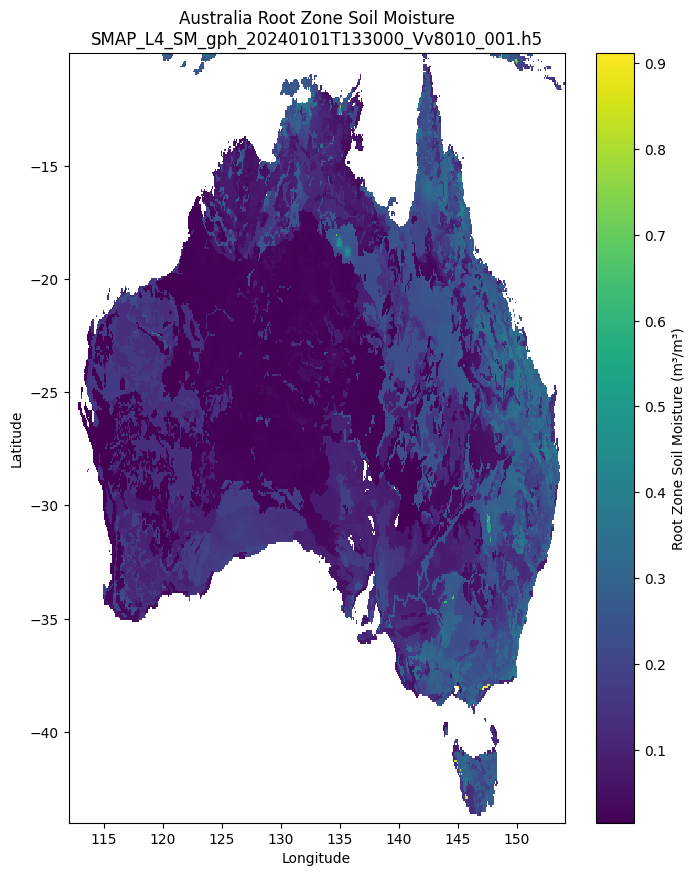

In [30]:
# Plot one example file

plot_australia_maps("SMAP_L4_SM_gph_20240101T133000_Vv8010_001.h5")

## Step 11: Compute average soil moisture over time

This step aggregates the Australia-only data by timestamp to observe how average moisture changes across the downloaded files.

In [31]:
# Group by timestamp and compute averages

time_series_df = (
    combined_df.groupby("timestamp")[["surface_soil_moisture", "rootzone_soil_moisture"]]
    .mean()
    .reset_index()
    .sort_values("timestamp")
)

display(time_series_df)

,timestamp,surface_soil_moisture,rootzone_soil_moisture
0,2023-12-31 22:30:00,0.103322,0.125288
1,2024-01-01 13:30:00,0.097684,0.124754
2,2024-01-02 13:30:00,0.105207,0.125554
3,2024-01-03 10:30:00,0.106604,0.125977
4,2024-01-03 22:30:00,0.117547,0.127409


## Step 12: Plot average soil moisture over time

This plot helps show temporal changes in soil moisture and can later be matched with fire occurrence data.

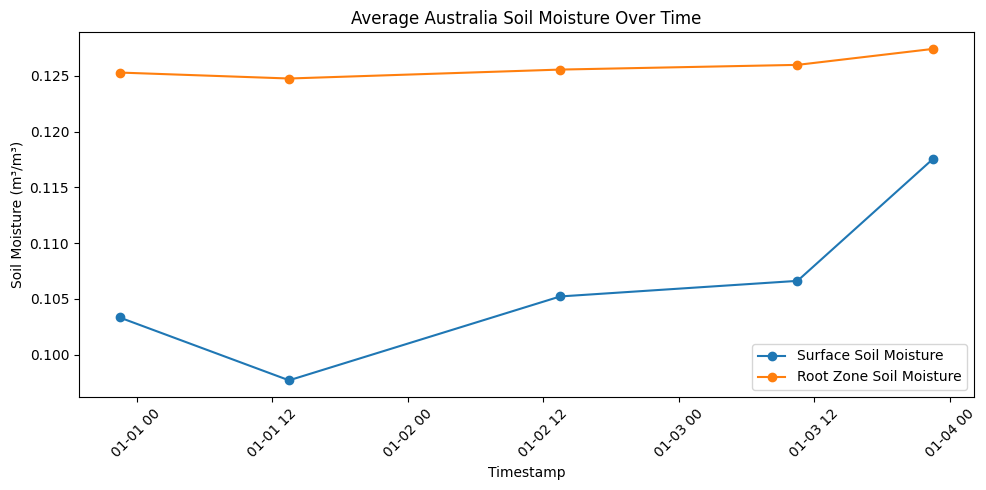

In [32]:
# Plot time series of average soil moisture

plt.figure(figsize=(10, 5))
plt.plot(
    time_series_df["timestamp"],
    time_series_df["surface_soil_moisture"],
    marker="o",
    label="Surface Soil Moisture"
)
plt.plot(
    time_series_df["timestamp"],
    time_series_df["rootzone_soil_moisture"],
    marker="o",
    label="Root Zone Soil Moisture"
)

plt.title("Average Australia Soil Moisture Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Soil Moisture (m³/m³)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Step 13: Export the cleaned dataset to CSV

This step saves the combined Australia-only dataset as a CSV file for further machine learning or backend integration.

In [33]:
# Save final dataset to CSV

output_csv = "australia_soil_moisture_dataset.csv"
combined_df.to_csv(output_csv, index=False)

print("CSV file saved as:", output_csv)
print("Total rows saved:", len(combined_df))

CSV file saved as: australia_soil_moisture_dataset.csv
Total rows saved: 485510


## Step 14: Preview the exported dataset

This is a final preview of the structured dataset that can be used later in the machine learning pipeline.

In [34]:
# Preview final dataset

display(combined_df.head(10))

,latitude,longitude,surface_soil_moisture,rootzone_soil_moisture,source_file,timestamp
0,-10.0414,119.922203,0.103387,0.183653,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00
1,-10.0414,120.015564,0.262688,0.328916,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00
2,-10.0414,120.108925,0.268914,0.324156,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00
3,-10.0414,120.202286,0.269646,0.335752,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00
4,-10.0414,120.295647,0.278558,0.342466,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00
5,-10.0414,120.389008,0.251336,0.304136,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00
6,-10.0414,120.482368,0.221551,0.285093,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00
7,-10.0414,120.575729,0.202996,0.266538,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00
8,-10.0414,120.669090,0.206780,0.263365,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00
9,-10.0414,120.762451,0.207940,0.256162,SMAP_L4_SM_gph_20231231T223000_Vv8010_001.h5,2023-12-31 22:30:00


## Step 15: How this dataset helps predict bushfires / forest fires

This dataset can contribute directly to bushfire and forest fire prediction because soil moisture is strongly related to land dryness.

### Why it matters
- **Low surface soil moisture** indicates dry topsoil and potentially dry vegetation.
- **Low root zone soil moisture** indicates prolonged dryness in deeper layers of the soil.
- Dry soil and dry vegetation increase the probability that a fire can start and spread more easily.

### How it can be used in a machine learning model
The exported CSV can later be merged with:
- weather data such as temperature, humidity, rainfall, and wind speed
- fire occurrence labels such as active fire detections or bushfire hotspot data
- vegetation and land cover information

### Example ML use
Each row in the final dataset can become part of a training sample with features such as:
- latitude
- longitude
- timestamp
- surface soil moisture
- root zone soil moisture

These features can later be combined with a target label such as:
- `fire_within_24h = 1`
- `fire_within_24h = 0`

This would allow the model to learn patterns such as:
- low soil moisture + high temperature + strong wind = higher fire risk

### Conclusion
The SMAP soil moisture dataset adds an important environmental signal to the FireFusion pipeline and can improve bushfire prediction by measuring how dry Australian land conditions are over space and time.

# Final Conclusion

In this notebook, the SMAP L4 soil moisture data source was successfully explored and processed.

### Achievements
- Multiple SMAP HDF5 files were loaded successfully
- Surface and root zone soil moisture were extracted
- The data was filtered to Australia only
- Australia-specific visualizations were created
- A combined CSV file was generated
- The relevance of soil moisture for bushfire prediction was explained

### Final Output
The exported CSV file:
`australia_soil_moisture_dataset.csv`

can now be used in the next stage of the FireFusion data pipeline, where it can be merged with weather, vegetation, and fire occurrence datasets for machine learning-based bushfire risk modelling.

## Main Findings and Conclusion

This project successfully processed NASA SMAP Level-4 soil moisture data from five HDF5 files and extracted key environmental variables for Australia, including surface soil moisture and root zone soil moisture.

The processed dataset contains over 485,000 records, with values falling within realistic physical ranges. Surface soil moisture ranged from approximately 0.0001 to 0.73 m³/m³, while root zone soil moisture ranged from approximately 0.015 to 0.91 m³/m³. These values confirm that the data extraction and cleaning pipeline is functioning correctly.

Spatial analysis of Australia revealed clear geographic patterns. Inland regions, particularly central Australia, exhibited lower soil moisture levels, indicating drier conditions. In contrast, coastal and eastern regions showed relatively higher moisture levels. This aligns with known climatic patterns in Australia and validates the correctness of the processed data.

Temporal analysis across multiple timestamps showed that surface soil moisture varies more rapidly than root zone soil moisture. Root zone moisture remained more stable, reflecting its deeper position in the soil profile, while surface moisture responded more quickly to environmental changes.

From a bushfire risk perspective, soil moisture is a critical environmental indicator. Lower soil moisture levels correspond to drier land and vegetation, which increases the likelihood of fire ignition and spread. However, soil moisture alone does not determine whether a fire will occur. Bushfire risk is influenced by multiple factors, including temperature, wind speed, humidity, and precipitation.

Therefore, this dataset is best understood as a feature input for bushfire prediction models rather than a direct indicator of fire occurrence. It provides valuable information about land dryness, which is one of the key conditions contributing to bushfire risk.

Overall, the project demonstrates that satellite-derived soil moisture data can be effectively processed, visualized, and used to support environmental monitoring and future machine learning models for bushfire prediction.